# Assignment 5: Large Language Models (48 marks total)
### Due: November 28 at 11:59pm

### Name: Alfarhana Siddique

The goal of the assignment is to practice using BERT. For this assignment, we will define our own BERT model and use manual training and testing loops.

## Part 1: BERT

### Step 0: Import Libraries

In [64]:
import pandas as pd
import torch
import numpy as np
from torch import nn
from torch.optim import Adam
from transformers import BertModel, BertTokenizer
import evaluate
import numpy as np
import torch
from tqdm import tqdm

from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import re

For more information on BertModel and BertTokenizer, check out https://huggingface.co/docs/transformers/en/model_doc/bert

### Part 1: Import Data (3 marks)

We will be using news stories from the BBC for this assignment. The csv file is included on D2L.

In [65]:
# TO DO: Import the data and print the first few rows (1 mark)
dataset = pd.read_csv("bbc-text.csv")
print(dataset.head())



        category                                               text
0           tech  tv future in the hands of viewers with home th...
1       business  worldcom boss  left books alone  former worldc...
2          sport  tigers wary of farrell  gamble  leicester say ...
3          sport  yeading face newcastle in fa cup premiership s...
4  entertainment  ocean s twelve raids box office ocean s twelve...


This dataset has five different categories for the different news articles. We can plot the data by category to see how many articles belong to each category.

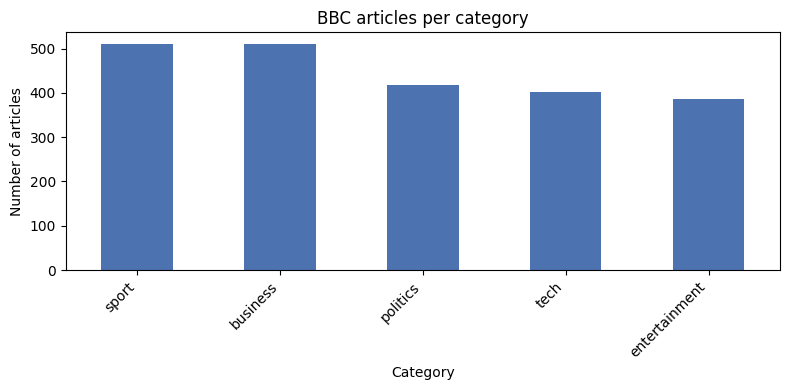

In [66]:
# TO DO: Bar plot to display number of articles per category (1 mark)

category_counts = dataset["category"].value_counts().sort_values(ascending=False)
ax = category_counts.plot(kind="bar", figsize=(8, 4), color="#4c72b0")
ax.set_title("BBC articles per category")
ax.set_xlabel("Category")
ax.set_ylabel("Number of articles")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


We need to split the data into training, validation and testing datasets. This code has been provided.

In [67]:
np.random.seed(112)
dataset_train, dataset_val, dataset_test = np.split(dataset.sample(frac=1, random_state=42), 
                                     [int(.8*len(dataset)), int(.9*len(dataset))])

print(len(dataset_train),len(dataset_val), len(dataset_test))



1780 222 223


/home/haroon/.local/lib/python3.11/site-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


We can create a labels dictionary for the different categories (the key is the category name, the value is a number (0-4)).

In [68]:
# TO DO: Create labels dictionary (1 mark)
dictionary = {label: idx for idx, label in enumerate(dataset["category"].unique())}
print(dictionary)


{'tech': 0, 'business': 1, 'sport': 2, 'entertainment': 3, 'politics': 4}


### Step 2: Model Definition (7 marks)

For our BERT model, we have two different options: uncased and cased. Uncased converts everything into lower case, while cased leaves the upper case letters as is. Select one of these options for this assignment (you will justify your choice in the questions).

We need to define the tokenizer for the data. The tokenizer we will be using is the `BertTokenizer`.

In [69]:
# TO DO: Define the tokenizer (1 mark)
MODEL_NAME = "bert-base-uncased"
MAX_SEQ_LEN = 512
BATCH_SIZE = 2

all_text = " ".join(dataset['text'])
no_of_caps = len(re.findall(r'[A-Z]', all_text))

print("capital letters:", no_of_caps) 


tokenizer = BertTokenizer.from_pretrained(MODEL_NAME)


capital letters: 0


We also need to define a custom Dataset class. For BERT, the input is limited to 512, so we can truncate to this length and pad anything shorter than this. Look at the tokenizer function that we are using to figure out what inputs we need to accomplish this. What return type should the tokenizer function have?

In [70]:
class Dataset(torch.utils.data.Dataset): 

    def __init__(self, dataset):
        # TO DO: Complete self.labels and self.text (2 marks)
        # self.labels = list of labels (numerical value)
        # self.texts = list with tokenized text data
        self.labels = dataset["category"].map(labels).astype(int).tolist()
        self.texts = []
        for text in dataset["text"].tolist():
            encoded = tokenizer(
                text,
                padding="max_length",
                truncation=True,
                max_length=MAX_SEQ_LEN,
                return_tensors="pt"
            )
            self.texts.append({key: value.squeeze(0) for key, value in encoded.items()})

        
    def classes(self):
        return self.labels

    def __len__(self):
        return len(self.labels)

    def get_batch_labels(self, idx):
        # Fetch a batch of labels
        return np.array(self.labels[idx])

    def get_batch_texts(self, idx):
        # Fetch a batch of inputs
        return self.texts[idx]

    def __getitem__(self, idx):

        batch_texts = self.get_batch_texts(idx)
        batch_y = self.get_batch_labels(idx)
        return batch_texts, batch_y

In [71]:
class BertClassifier(nn.Module):

    def __init__(self, dropout=0.5):
        super(BertClassifier, self).__init__()
        # TO DO: Define the bert, dropout, linear and ReLU layers (2 marks)
        self.bert = BertModel.from_pretrained(MODEL_NAME)
        self.dropout = nn.Dropout(dropout)
        self.linear = nn.Linear(self.bert.config.hidden_size, len(labels))
        self.relu = nn.ReLU()
        


    def forward(self, input_id, mask):
        # TO DO: Complete the steps for the bert model (2 marks)
        # Look at the data and the bert model documentation for hints on how to complete this
        outputs = self.bert(input_ids=input_id, attention_mask=mask)
        pooled_output = outputs.pooler_output
        dropped = self.dropout(pooled_output)
        logits = self.linear(dropped)
        return self.relu(logits)

    
model = BertClassifier()


### Step 3: Model Training and Validation (20 marks)

We can use our custom dataset class to process the data before loading the data into dataloaders.

In [72]:
# TO DO: Convert training, validation and testing data into dataloaders - use batch_size = 2 (3 marks)


train_dataset = Dataset(dataset_train)
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_dataset = Dataset(dataset_val)
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_dataset = Dataset(dataset_test)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f"Using device: {device}")


Using device: cuda


For this case, we can use `CrossEntropyLoss()` and `Adam()` for our optimization.

In [73]:
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr = 1e-6)


The last element we need to define is the BERT classifier. For this assignment, we will be using `BertModel`. The output of the BERT model is an embedding vector with length 768. We will need a one-layer neural network for the classification portion (you can define a `ReLU()` step after the linear layer). You can use a dropout layer before the linear layer to help with generalization.

We can use the accuracy metrics from the `evaluate` library for training and evaluation. We will use accuracy and f1 score for this case.

In [74]:
# TO DO: Load the metrics for training and evaluation (1 mark)
Accuracy_metric = "accuracy"
F1_score = "f1"

def init_metrics():

    return evaluate.load(Accuracy_metric), evaluate.load(F1_score)


The next step is to define the training and evaluation loops. You may need to look at the data to determine the model inputs. You can use `tqdm` to create a progress bar to see the status of your code.

In [75]:
# TO DO: Training loop (6 marks)
def train_one_epoch(model, dataloader, optimizer, criterion):
    model.train()
    accuracy_metric, f1_metric = init_metrics()
    running_loss = 0.0

    progress = tqdm(dataloader, leave=False)
    for batch_texts, batch_labels in progress:
        optimizer.zero_grad()
        input_ids = batch_texts["input_ids"].to(device)
        mask = batch_texts["attention_mask"].to(device)
        labels = batch_labels.to(device)

        outputs = model(input_ids, mask)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = outputs.argmax(dim=1).detach().cpu().numpy()
        refs = labels.detach().cpu().numpy()
        accuracy_metric.add_batch(predictions=preds, references=refs)
        f1_metric.add_batch(predictions=preds, references=refs)
        progress.set_postfix(loss=loss.item())

    avg_loss = running_loss / max(1, len(dataloader))
    accuracy = accuracy_metric.compute()["accuracy"]
    f1_score = f1_metric.compute(average="weighted")["f1"]
    return {"loss": avg_loss, "accuracy": accuracy, "f1": f1_score}


In [76]:
# TO DO: Evaluation loop (5 marks)
def evaluate_model(model, dataloader, criterion):
    model.eval()
    accuracy_metric, f1_metric = init_metrics()
    running_loss = 0.0

    progress = tqdm(dataloader, leave=False)
    with torch.no_grad():
        for batch_texts, batch_labels in progress:
            input_ids = batch_texts["input_ids"].to(device)
            mask = batch_texts["attention_mask"].to(device)
            labels = batch_labels.to(device)

            outputs = model(input_ids, mask)
            loss = criterion(outputs, labels)
            running_loss += loss.item()

            preds = outputs.argmax(dim=1).detach().cpu().numpy()
            refs = labels.detach().cpu().numpy()
            accuracy_metric.add_batch(predictions=preds, references=refs)
            f1_metric.add_batch(predictions=preds, references=refs)
            progress.set_postfix(loss=loss.item())

    avg_loss = running_loss / max(1, len(dataloader))
    accuracy = accuracy_metric.compute()["accuracy"]
    f1_score = f1_metric.compute(average="weighted")["f1"]
    return {"loss": avg_loss, "accuracy": accuracy, "f1": f1_score}


Create a function that can be used to help you print the results for both the accuracy and f1 score.

In [77]:
# TO DO: Printing function (1 mark)
def print_metrics(stage, metrics):
    print(f"{stage}:")
    print(f"  loss: {metrics['loss']:.4f}")
    print(f"  accuracy: {metrics['accuracy']:.4f}")
    print(f"  f1-score: {metrics['f1']:.4f}")
    print() 



As stated in class, BERT is a pre-trained model that we can augment with additional data. What happens when we run the testing data on the BERT model without fine-tuning?

In [78]:
# TO DO: Test without fine-tuning and print results (1 mark)
pretrained_test_metrics = evaluate_model(
    model, test_dataloader, criterion
)
print_metrics("Test without fine-tuning", pretrained_test_metrics)


Test without fine-tuning:
  loss: 1.6182
  accuracy: 0.2556
  f1-score: 0.1137



Now we can fine-tune the model by training it with the BBC news data. For this assignment, we will only run one epoch, as it takes a long time to run.

In [79]:
# TO DO: Run one epoch for training and validation data and print results (2 marks)
train_metrics = train_one_epoch(model, train_dataloader, optimizer, criterion)
print_metrics("Train (epoch 1)", train_metrics)

val_metrics = evaluate_model(model, val_dataloader, criterion)
print_metrics("Validation (epoch 1)", val_metrics)


Train (epoch 1):
  loss: 1.4998
  accuracy: 0.3815
  f1-score: 0.3231



Validation (epoch 1):
  loss: 1.3393
  accuracy: 0.5180
  f1-score: 0.3951



Now we can test the model again after fine-tuning.

In [80]:
# TO DO: Test the model (1 mark)
fine_tuned_test_metrics = evaluate_model(
    model, test_dataloader, criterion, 
)
print_metrics("Test after fine-tuning", fine_tuned_test_metrics)


Test after fine-tuning:
  loss: 1.2625
  accuracy: 0.5964
  f1-score: 0.4829



## Part 2: Questions and Process Description

### Questions (12 marks)

1. Which version of BERT did you select? Why?
1. What are the pros and cons of using uncased compared to cased?
1. What potential issues arise when truncating long news headlines or articles?
1. How did the model work without fine-tuning? Why do you think it worked this way?
1. How might a news classifier using a pre-trained model inadvertently encode bias?
1. Why is F1-score sometimes more informative than accuracy on text classification?

*ANSWER HERE*

1. I selected bert-base-uncased because the dataset had 0 capital letters

1. depends on the dataset. if it did have capital letters then cased woudl be better since with would be able to read them, for example if a word is a name. if the dataset doesnt include any capital letters then theres no use for cased, uncased would be better.

1. could cut out important information that could give the headline or article more context or an ending.

1. without fine tuning, the performance was bad since the model wasnt trained on the specific dataset for example headlines. it had no context and only generally understood the language.

1. it would depend on the dataset taht was used to train it. if the dataset was biased or sourced from a biased source then the model would then be biased

1. F1 combines precision and recall, so the frequency of a class would not make the model predict it and hence accidently getting it right.


### Process Description (4 marks)
Please describe the process you used to create your code. Cite any websites or generative AI tools used. You can use the following questions as guidance:
1. Where did you source your code?
1. In what order did you complete the steps?
1. If you used generative AI, what prompts did you use? Did you need to modify the code at all? Why or why not?
1. Did you have any challenges? If yes, what were they? If not, what helped you to be successful?

*DESCRIBE YOUR PROCESS HERE - BE SPECIFIC*

1.i used gpt to help me debug some of the issue i had, for the rest i used the class examples as a guide

2.in the order the questions were given in 

3.i mainly used gpt for debugging and sometimes for a discussion on how i could improve my code

4.using cpu in the beginning was a hassel. it took a lot of time for it to finish. switching from my laptop to my gaming pc with a nvidia card and leveraged cuda


## Part 3: Reflection (2 marks)
Include a sentence or two about:
- what you liked or disliked,
- found interesting, confusing, challenging, motivating
while working on this assignment.


*ADD YOUR THOUGHTS HERE*

i liked the difference in time it took to run the model with the cpu first and then with the gpu. it was very satisfying to see.
showing us how important it is to inspect the dataset before trainimg the model was nice and i found it very interesting how a biased datatset could make the model biased too.